In [16]:
# Import modules
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *

import numpy as np 
import matplotlib.pyplot as plt
from NuOscProbExact.src import  oscprob2nu, globaldefs, hamiltonians2nu
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import copy as cp

In [17]:
def gaus(x,p0,p1,p2):
    return p0 * math.e**((-0.5 * (x - p1)**2)/ p2**2)

# Function to generate counts from a Poisson distribution based on probabilities and Gaussian scaling    
def poisson_dist(probability, bin_centers, amplitude, mean, sigma):
    counts = np.random.poisson(probability * gaus(bin_centers,amplitude,mean,sigma)) 
    return counts


In [18]:
# parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

adjusted_counts_fd = np.array([ 0.  ,  7.5 ,  1.  ,  3.  ,  1.  ,  2.  ,  2.  ,  4.  ,  6.  ,
        9.  , 15.  , 12.  , 39.5 , 25.  , 19.25, 20.25, 16.  , 14.  ,
       18.  ])
adjusted_counts_nd = np.array([ 37500., 105000.,  72000.,  96000., 120000., 148000., 170000.,
       192000., 208000., 214000., 212000., 204000., 425000., 280000.,
       181500.,  81000.,  80000.,  25000.,  10000.])

length_nd = 1 # [km]
length_fd = 810 # [km]

In [19]:
print(np.sum(adjusted_counts_fd))
print(np.sum(adjusted_counts_nd))
print(np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd))

214.5
2861000.0
7.497378538972387e-05


Fitted parameters for observed the unoscillated ND events: Amplitude = 212.76692699546734, Mean = 1.8044188236655974, Sigma = 0.5254484171717854
Fitted parameters for observed the oscillated FD events: Amplitude = 13.876745944019577, Mean = 2.211417891318019, Sigma = 0.4952413577763477


Text(0.5, 0, 'Energy (GeV)')

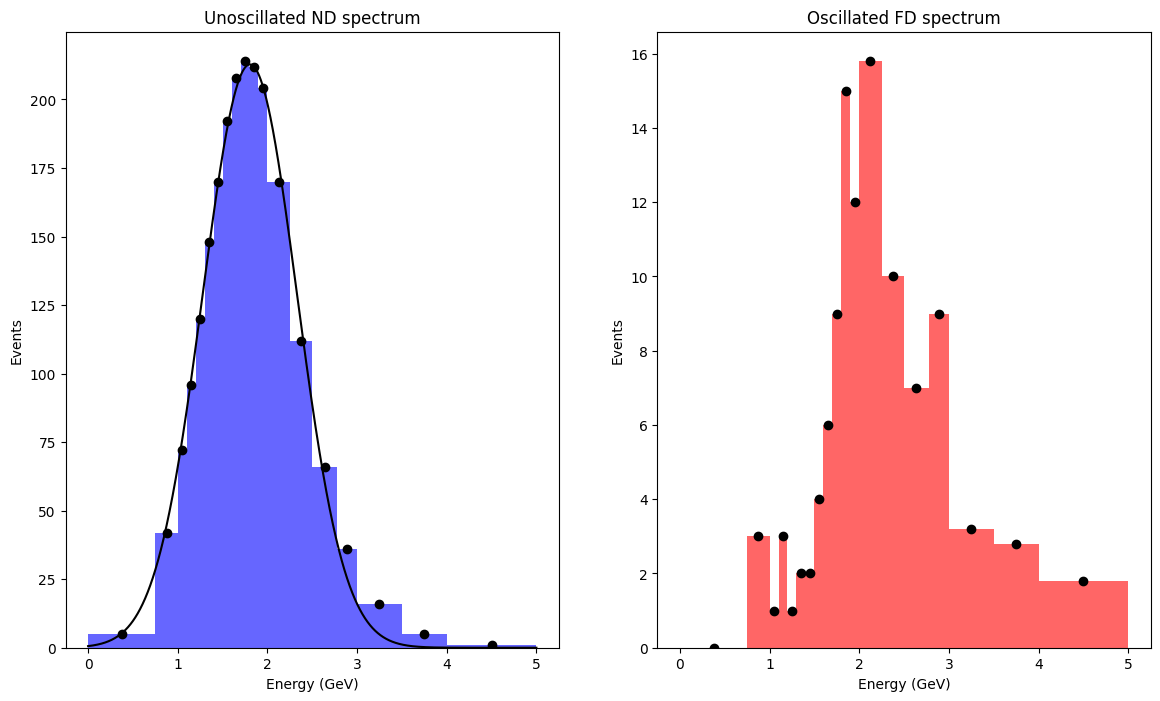

In [20]:
initial_guess_nd = [140,2,0.5]
initial_guess_fd = [8, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess_nd)
popt_fd, _ = curve_fit(gaus, bin_centers, counts_fd, p0=initial_guess_fd)

print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")
print(f"Fitted parameters for observed the oscillated FD events: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")

fig, axs = plt.subplots(1, 2, figsize=(14, 8))

x = np.arange(0.0001,5,0.0001)

axs[0].hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.6, color='b')
axs[0].scatter(bin_centers, counts_nd, color='black')
axs[0].plot(x, gaus(x,*popt_nd), color='black')
axs[0].set_title("Unoscillated ND spectrum")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")

axs[1].hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.6, color='r')
axs[1].scatter(bin_centers, counts_fd, color='black')
#axs[1].plot(x, gaus(x, *popt_fd), color='black')
axs[1].set_title("Oscillated FD spectrum")
axs[1].set_ylabel("Events")
axs[1].set_xlabel("Energy (GeV)")

In [21]:
def osc_probability_2nu_1(sector, case, length, transition):
    """
    Calculate oscillation probabilities for 2-neutrino systems.

    Parameters:
    - sector: str, '12' or '23'
    - case: str, 'vacuum' or 'matter'
    - length: float, in kilometers
    - transition: str, 'me', 'mm', or 'mt'

    Returns:
    - List of probabilities for the specified transition
    """
    # Convert energy to eV
    probabilities = []
    energy = x * 1e9

    # Sector-specific parameters
    if sector == '12':
        mixing_angle = globaldefs.S12_NO_BF
        delta_mass_squared = globaldefs.D21_NO_BF
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = globaldefs.S23_NO_BF
        delta_mass_squared = globaldefs.D31_NO_BF
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")

    # Determine the index for the transition
    index1 = transition_map.get(transition)
    if index1 is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")

    # Calculate energy-independent vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)
    #print('Hamiltonian = ', h_vacuum_energy_indep)

    # Scaling factor for length
    length_scaled = length * globaldefs.CONV_KM_TO_INV_EV

    # Define a function for Hamiltonian calculation
    if case == 'vacuum':
        def calculate_hamiltonian(e): 
            return h_vacuum_energy_indep / e
    elif case == 'matter':
        def calculate_hamiltonian(e): return hamiltonians2nu.hamiltonian_2nu_matter(h_vacuum_energy_indep, e, globaldefs.VCC_EARTH_CRUST)
    else:
        raise ValueError(f"Invalid case '{case}'. Must be 'vacuum' or 'matter'.")
    
    # Compute probabilities
    probabilities = [
        oscprob2nu.probabilities_2nu(calculate_hamiltonian(e), length_scaled)[index1]
        for e in energy
    ]

    return probabilities

def osc_probability_2nu(sector, case, length, transition):
    """
    Calculate oscillation probabilities for 2-neutrino systems.

    Parameters:
    - sector: str, '12' or '23'
    - case: str, 'vacuum' or 'matter'
    - length: float, in kilometers
    - transition: str, 'me', 'mm', or 'mt'

    Returns:
    - List of probabilities for the specified transition
    """
    # Convert energy to eV
    energy = bin_centers * 1e9
    probabilities = []

    # Sector-specific parameters
    if sector == '12':
        mixing_angle = globaldefs.S12_NO_BF
        delta_mass_squared = globaldefs.D21_NO_BF
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = globaldefs.S23_NO_BF
        delta_mass_squared = globaldefs.D31_NO_BF
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")

    # Determine the index for the transition
    index1 = transition_map.get(transition)
    if index1 is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")

    # Calculate energy-independent vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)
    print(h_vacuum_energy_indep)

    # Scaling factor for length
    length_scaled = length * globaldefs.CONV_KM_TO_INV_EV

    # Define a function for Hamiltonian calculation
    if case == 'vacuum':
        def calculate_hamiltonian(e): return h_vacuum_energy_indep / e
    elif case == 'matter':
        def calculate_hamiltonian(e): return hamiltonians2nu.hamiltonian_2nu_matter(h_vacuum_energy_indep, e, globaldefs.VCC_EARTH_CRUST)
    else:
        raise ValueError(f"Invalid case '{case}'. Must be 'vacuum' or 'matter'.")
    
    # Compute probabilities
    probabilities = [
        oscprob2nu.probabilities_2nu(calculate_hamiltonian(e), length_scaled)[index1]
        for e in energy
    ]

    return probabilities

def plot_osc_2nu_1(sector, case, length, transition):

    probabilities = osc_probability_2nu_1(sector, case, length, transition)
    #print(f'Osc probs = ', probabilities)

    popt = popt_nd
    weights = counts_nd

    # Maps the lengths to their repestive titles
    title_map = {
        length_nd: 'Unoscillated vs Oscillated Neutrino Events in ND',
        length_fd: 'Unoscillated vs Oscillated Neutrino Events in FD'
    }
    title_text1 = title_map.get(length, 'Unknown')
    fit_oscillation = (length == length_nd)
    title_text2 = 'In Matter' if case == 'matter' else 'In Vacuum'
    full_title = f'{title_text1} {title_text2}'

    # Set labels and event index based on the transition type
    label_map = {
        'me': ('μ → e events', 'Gaussian (μ → e) events fit', 2),
        'mt': ('μ → τ events', 'Gaussian (μ → τ) events fit', 2),
        'mm': ('μ → μ events', 'Gaussian (μ → μ) events fit', 0),
    }
    event_label, gaussian_fit_label, index = label_map.get(transition, ('Unknown transition', '', 0))

    fluc_osc_counts = poisson_dist(probabilities, x, *popt)
    print('Fluc osc counts:', fluc_osc_counts)
    osc_counts = probabilities * gaus(x, *popt)
    print('Osc counts:', osc_counts)

    bin_indices = np.digitize(x, bin_edges)
    fluc_bin_weights = np.zeros(len(bin_edges) - 1)

    for i in range(1, len(bin_edges)):
        fluc_bin_weights[i-1] = fluc_osc_counts[bin_indices == i].sum()
    
    bin_widths = np.diff(bin_edges)
    scaling_factor = bin_widths * (1000 / 0.1)
    true_fluc_bin_weights = fluc_bin_weights / scaling_factor

    bin_weights = np.zeros(len(bin_edges) - 1)

    for i in range(1, len(bin_edges)):
        bin_weights[i-1] = osc_counts[bin_indices == i].sum()

    true_osc_bin_weights = bin_weights / scaling_factor

    fig, axs = plt.subplots(1, 2, figsize=(14, 8))
    
    # First subplot: with Poisson dist
    axs[0].hist(bin_edges[:-1],bin_edges ,weights=weights, histtype='step', alpha=0.6, color='r', label='Unoscillated Events')
    axs[0].plot(x, gaus(x,*popt_nd), color='green', label='Gaussian Unoscillated Events')
    axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=true_fluc_bin_weights, histtype='step',density=False,
                alpha=0.6, color='b', label=event_label)

    if fit_oscillation:
        popt_fluc_osc, _ = curve_fit(gaus, bin_centers, true_fluc_bin_weights)
        axs[0].plot(bin_centers, true_fluc_bin_weights, color='black',label=gaussian_fit_label)

    axs[0].set_title(full_title)
    axs[0].set_xlabel('Energy (GeV)')
    axs[0].set_ylabel('Events')
    axs[0].legend()
    axs[0].grid()

    # Second subplot: without Poisson dist
    axs[1].hist(bin_edges[:-1],bin_edges ,weights=weights, histtype='step', alpha=0.6, color='r', label='Unoscillated Events')
    axs[1].plot(x, gaus(x,*popt_nd), color='green', label='Gaussian Unoscillated Events')
    axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=true_osc_bin_weights, histtype='step',density=False, 
                alpha=0.6, color='b', label=event_label)
    
    if fit_oscillation:
        axs[1].plot(x, osc_counts, color='black',label=gaussian_fit_label)

    axs[1].set_title(full_title + ' (No Poisson Fluctuations)')
    axs[1].set_xlabel('Energy (GeV)')
    axs[1].set_ylabel('Events')
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()
    
    return

Sum of nd events =  2801527.3288631123


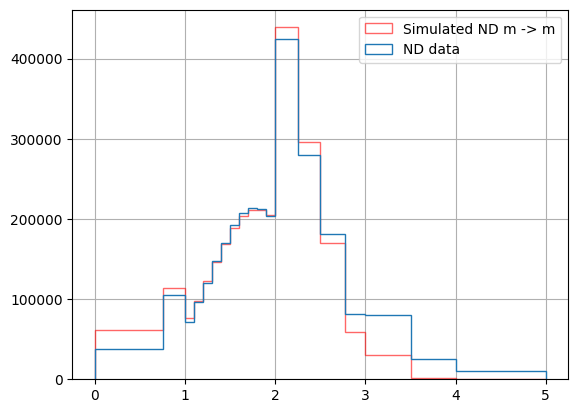

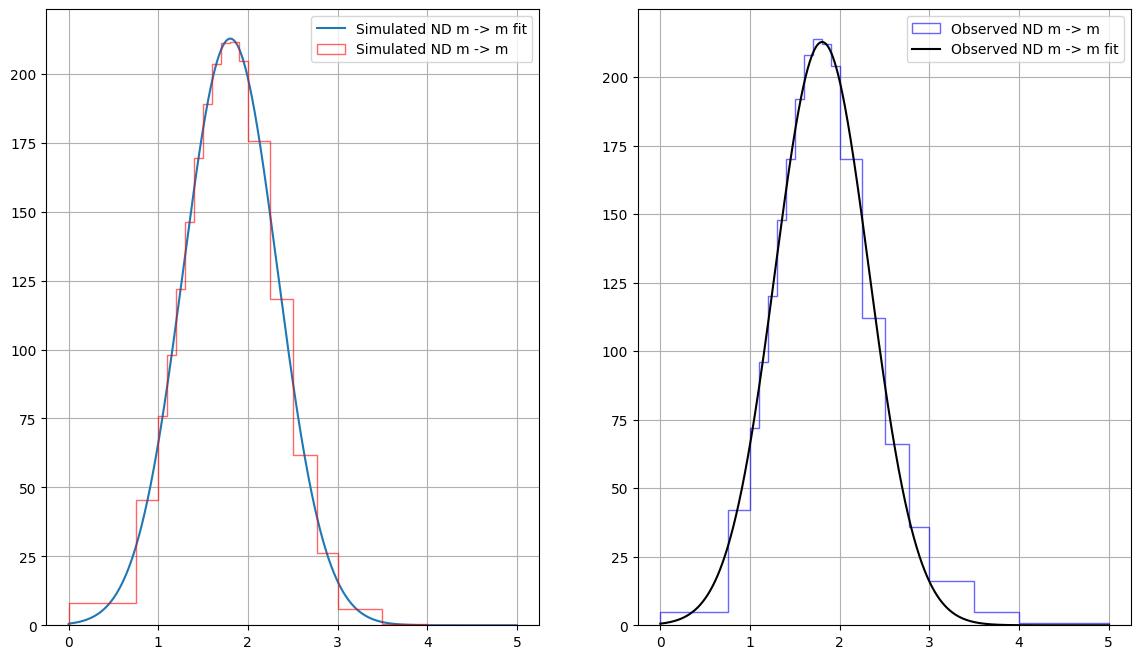

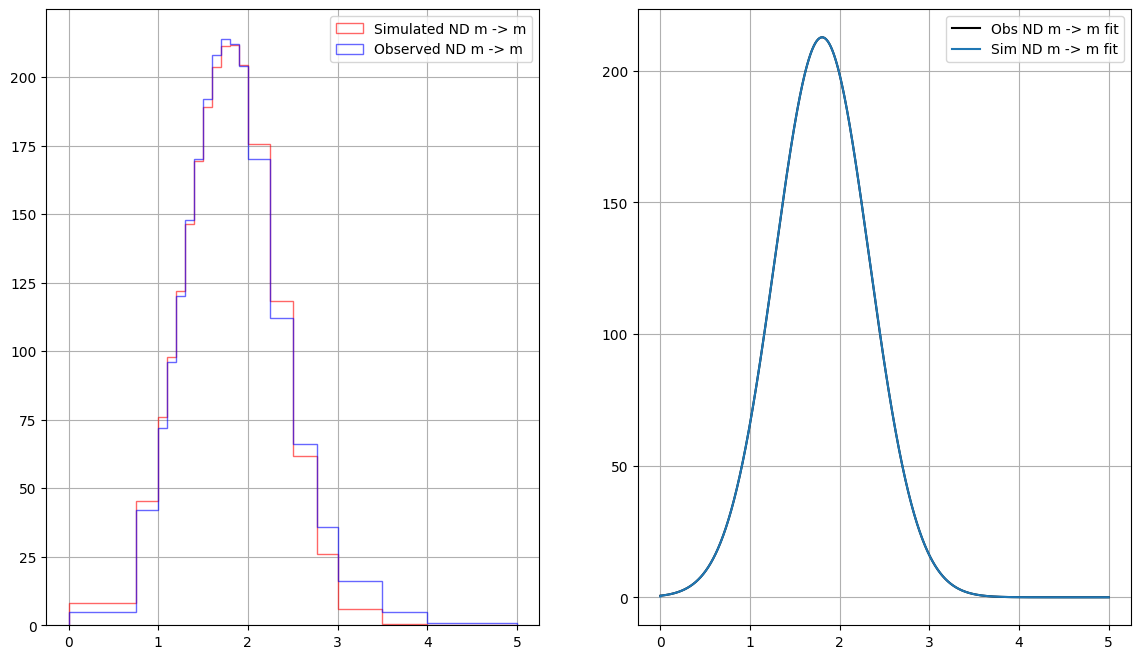

In [22]:
prob1 = osc_probability_2nu_1('12', 'vacuum', length_nd, 'mm') # osc prob calculated for each energy bin
#print('Probability of m -> m transition',prob1)

gaus1 = gaus(x, *popt_nd)
#print(gaus1)

osc_prob1 = prob1 * gaus1
#print('Oscillated m -> m data', osc_prob1)

bin_indices = np.digitize(x, bin_edges)
bin_weights = np.zeros(len(bin_edges) - 1)

for i in range(1, len(bin_edges)):
    bin_weights[i-1] = osc_prob1[bin_indices == i].sum()

#print('Bin weights = ',bin_weights)
print('Sum of nd events = ', np.sum(bin_weights))

bin_widths = np.diff(bin_edges)
scaling_factor = bin_widths * (1000 / 0.1)

bin_weights1 = bin_weights / scaling_factor 
#print(bin_weights1)

plt.figure()
plt.hist(bin_edges[:-1], bin_edges, weights = bin_weights, alpha=0.6,histtype='step',label='Simulated ND m -> m', color='red')
plt.hist(bin_edges[:-1], bin_edges, weights=adjusted_counts_nd, label='ND data', histtype='step')
plt.legend()
plt.grid()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 8))

axs[0].plot(x, osc_prob1, label='Simulated ND m -> m fit')
axs[0].hist(bin_edges[:-1], bin_edges, weights =bin_weights1, alpha=0.6,histtype='step',label='Simulated ND m -> m', color='red')
axs[0].legend()
axs[0].grid()

axs[1].hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.6, histtype='step',color='b', label='Observed ND m -> m')
axs[1].plot(x, gaus(x,*popt_nd), color='black', label='Observed ND m -> m fit')

plt.legend()
plt.grid()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 8))
axs[0].hist(bin_edges[:-1], bin_edges, weights =bin_weights1, alpha=0.6,histtype='step',label='Simulated ND m -> m', color='red')
axs[0].hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.6, histtype='step',color='b', label='Observed ND m -> m')
axs[0].grid()
axs[0].legend()


axs[1].plot(x, gaus(x,*popt_nd), color='black', label='Obs ND m -> m fit')
axs[1].plot(x, osc_prob1, label='Sim ND m -> m fit')
axs[1].grid()
axs[1].legend()
plt.show()

Sum of fd events =  556056.6717372541
0.19848340082511617


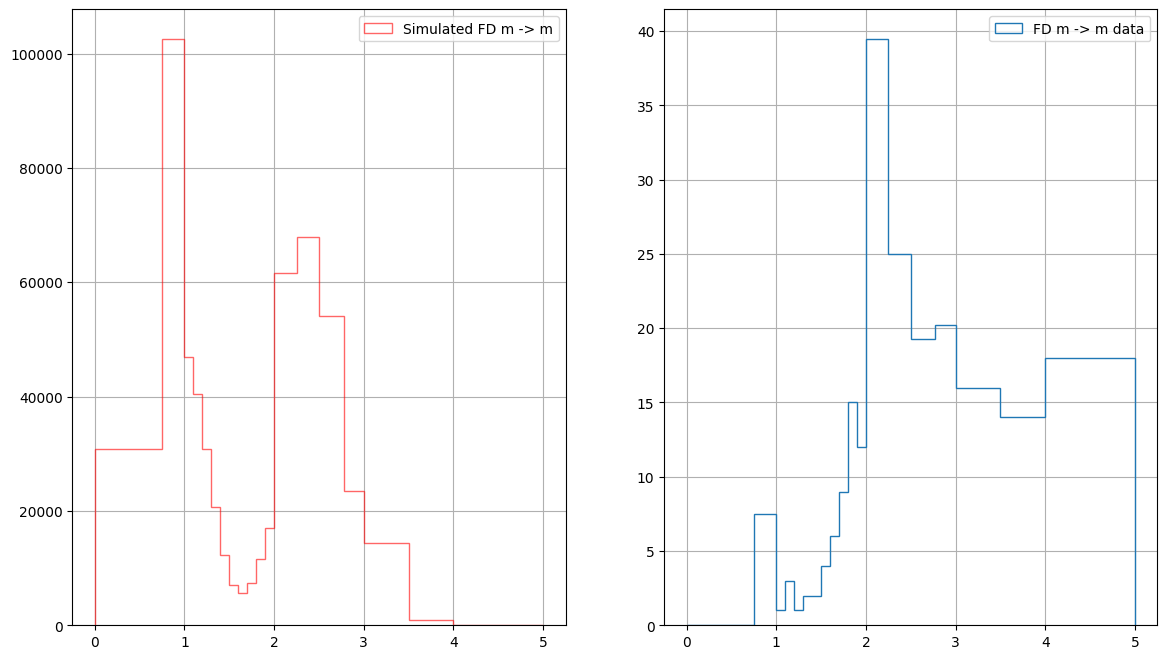

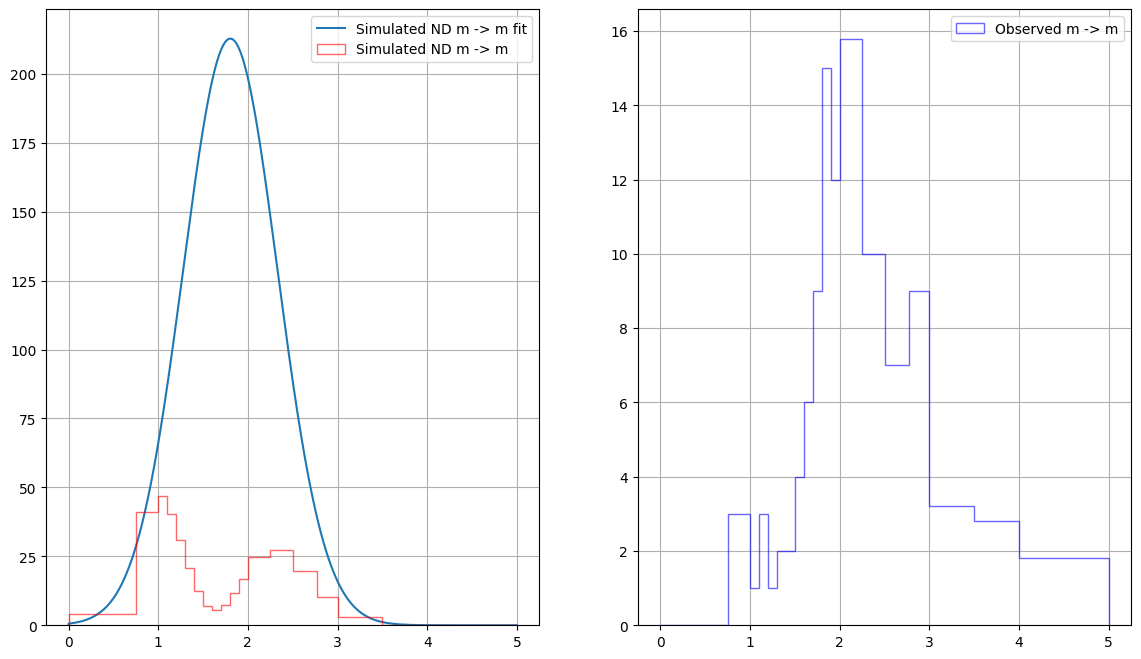

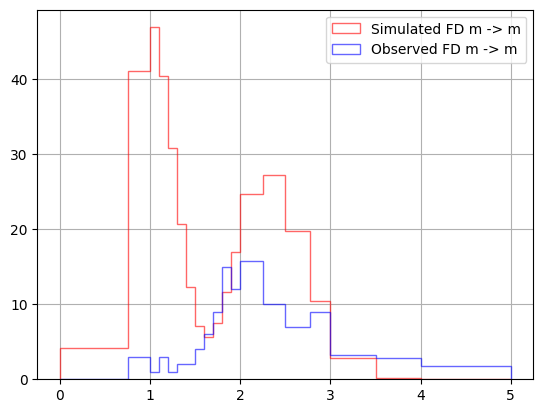

In [23]:
test_prob2 = osc_probability_2nu_1('23', 'vacuum', length_fd, 'mm')
#print(test_prob2)

osc_prob2 = test_prob2 * gaus(x, *popt_nd)
#print(osc_prob2)

bin_weights2 = np.zeros(len(bin_edges) - 1)

for i in range(1, len(bin_edges)):
    bin_weights2[i-1] = osc_prob2[bin_indices == i].sum()

#print('Bin weights = ',bin_weights2)
print('Sum of fd events = ', np.sum(bin_weights2))

print(np.sum(bin_weights2) / np.sum(bin_weights))

bin_weights3 = bin_weights2 / scaling_factor
#print(bin_weights3)

fig, axs = plt.subplots(1, 2, figsize=(14, 8))
axs[0].hist(bin_edges[:-1], bin_edges, weights=bin_weights2, alpha=0.6,histtype='step',label='Simulated FD m -> m', color='red')
axs[0].legend()
axs[0].grid()

axs[1].hist(bin_edges[:-1], bin_edges, weights=adjusted_counts_fd, label='FD m -> m data', histtype='step')
axs[1].legend()
axs[1].grid()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 8))

axs[0].plot(x, osc_prob1, label='Simulated ND m -> m fit')
axs[0].hist(bin_edges[:-1], bin_edges, weights =bin_weights3, alpha=0.6,histtype='step',label='Simulated ND m -> m', color='red')
axs[0].legend()
axs[0].grid()

axs[1].hist(bin_edges[:-1],bin_edges ,weights=counts_fd, density=False, alpha=0.6, histtype='step',color='b', label='Observed m -> m')
#axs[1].plot(bin_centers, gaus(bin_centers,*popt_nd), color='black')

plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.hist(bin_edges[:-1], bin_edges, weights =bin_weights3, alpha=0.6,histtype='step',label='Simulated FD m -> m', color='red')
plt.hist(bin_edges[:-1],bin_edges ,weights=counts_fd, density=False, alpha=0.6, histtype='step',color='b', label='Observed FD m -> m')
plt.grid()
plt.legend()
plt.show()

In [24]:
def plot_osc_2nu(sector, case, length, transition):
    # Calculate the oscillation probabilities based on the specified sector, case, and length
    """
    Parameters:
    - sector: str, oscillation sector ('12' or '23')
    - case: str, either 'vacuum' or 'matter'
    - length: int, detector length (1, 810)
    - transition: str, type of transition ('me', 'mm', 'mt')
    """
    # Calculate the oscillatoin probabilities
    probabilities = osc_probability_2nu(sector, case, length, transition)
    print(f'Probabilitities: ', probabilities)
    
    popt = popt_nd
    weights = counts_nd

    # Maps the lengths to their repestive titles
    title_map = {
        length_nd: 'Unoscillated vs Oscillated Neutrino Events in ND',
        length_fd: 'Unoscillated vs Oscillated Neutrino Events in FD'
    }
    title_text1 = title_map.get(length, 'Unknown')
    fit_oscillation = (length == length_nd)
    title_text2 = 'In Matter' if case == 'matter' else 'In Vacuum'
    full_title = f'{title_text1} {title_text2}'

    # Set labels and event index based on the transition type
    label_map = {
        'me': ('μ → e events', 'Gaussian (μ → e) events fit', 2),
        'mt': ('μ → τ events', 'Gaussian (μ → τ) events fit', 2),
        'mm': ('μ → μ events', 'Gaussian (μ → μ) events fit', 0),
    }
    event_label, gaussian_fit_label, index = label_map.get(transition, ('Unknown transition', '', 0))

    # Calculate the Poisson-distributed counts for the oscillated events
    counts = poisson_dist(probabilities, bin_centers, *popt)
    counts_without_poisson_dist = probabilities * gaus(bin_centers, *popt)
    
    # Start plotting
    fig, axs = plt.subplots(1, 2, figsize=(14, 8))
    x = np.arange(0,5,0.001)

    # First subplot: with Poisson dist
    axs[0].hist(bin_edges[:-1],bin_edges ,weights=weights, histtype='step', alpha=0.6, color='r', label='Unoscillated Events')
    axs[0].plot(x, gaus(x,*popt_nd), color='green', label='Gaussian Unoscillated Events')
    axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts, histtype='step',density=False,
                alpha=0.6, color='b', label=event_label)

    if fit_oscillation:
        popt_osc, _ = curve_fit(gaus, bin_centers, counts)
        print(f"Fitted parameters for observed events: Amplitude = {popt_osc[0]}, Mean = {popt_osc[1]}, Sigma = {popt_osc[2]}")
        axs[0].plot(x, gaus(x, *popt_osc), color='black',label=gaussian_fit_label)

    axs[0].set_title(full_title)
    axs[0].set_xlabel('Energy (GeV)')
    axs[0].set_ylabel('Events')
    axs[0].legend()
    axs[0].grid()

    # Second subplot: without Poisson dist
    axs[1].hist(bin_edges[:-1],bin_edges ,weights=weights, histtype='step', alpha=0.6, color='r', label='Unoscillated Events')
    axs[1].plot(x, gaus(x,*popt_nd), color='green', label='Gaussian Unoscillated Events')
    axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_without_poisson_dist, histtype='step',density=False, 
                alpha=0.6, color='b', label=event_label)
    
    if fit_oscillation:
        popt_unfluc, _ = curve_fit(gaus, bin_centers, counts_without_poisson_dist)
        axs[1].plot(x, gaus(x, *popt_unfluc), color='black',label=gaussian_fit_label)

    axs[1].set_title(full_title + ' (No Poisson Fluctuations)')
    axs[1].set_xlabel('Energy (GeV)')
    axs[1].set_ylabel('Events')
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()



Fluc osc counts: [0 1 0 ... 0 0 0]
Osc counts: [4.17355210e-01 5.40056213e-01 7.64360367e-02 ... 1.98592997e-06
 1.98363293e-06 1.98133847e-06]


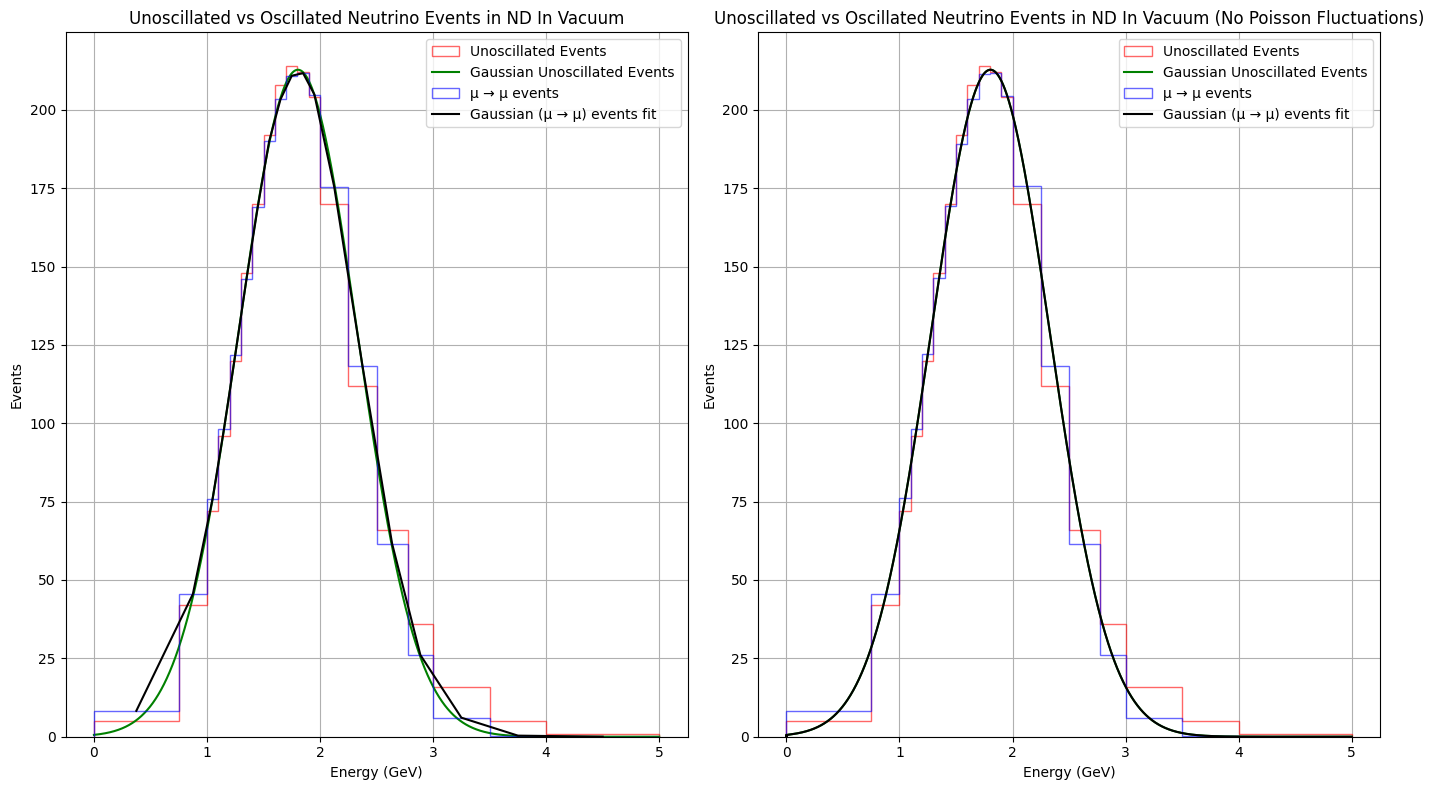

[[-0.00010352499999999993, -0.0006227030888593697], [-0.0006227030888593697, 0.00010352499999999993]]
Probabilitities:  [0.9999291865250836, 0.9999869931858231, 0.9999909674778581, 0.9999924700485543, 0.9999936266465712, 0.9999945358749882, 0.999995263557519, 0.9999958549959068, 0.9999963421950429, 0.9999967482855899, 0.9999970903209503, 0.999997381097294, 0.9999977946842462, 0.9999982345253494, 0.9999985684588806, 0.9999988056137, 0.9999990571944846, 0.9999992918482448, 0.9999995082279113]
Fitted parameters for observed events: Amplitude = 206.81155487830281, Mean = 1.7971488030008598, Sigma = 0.5263475908598737


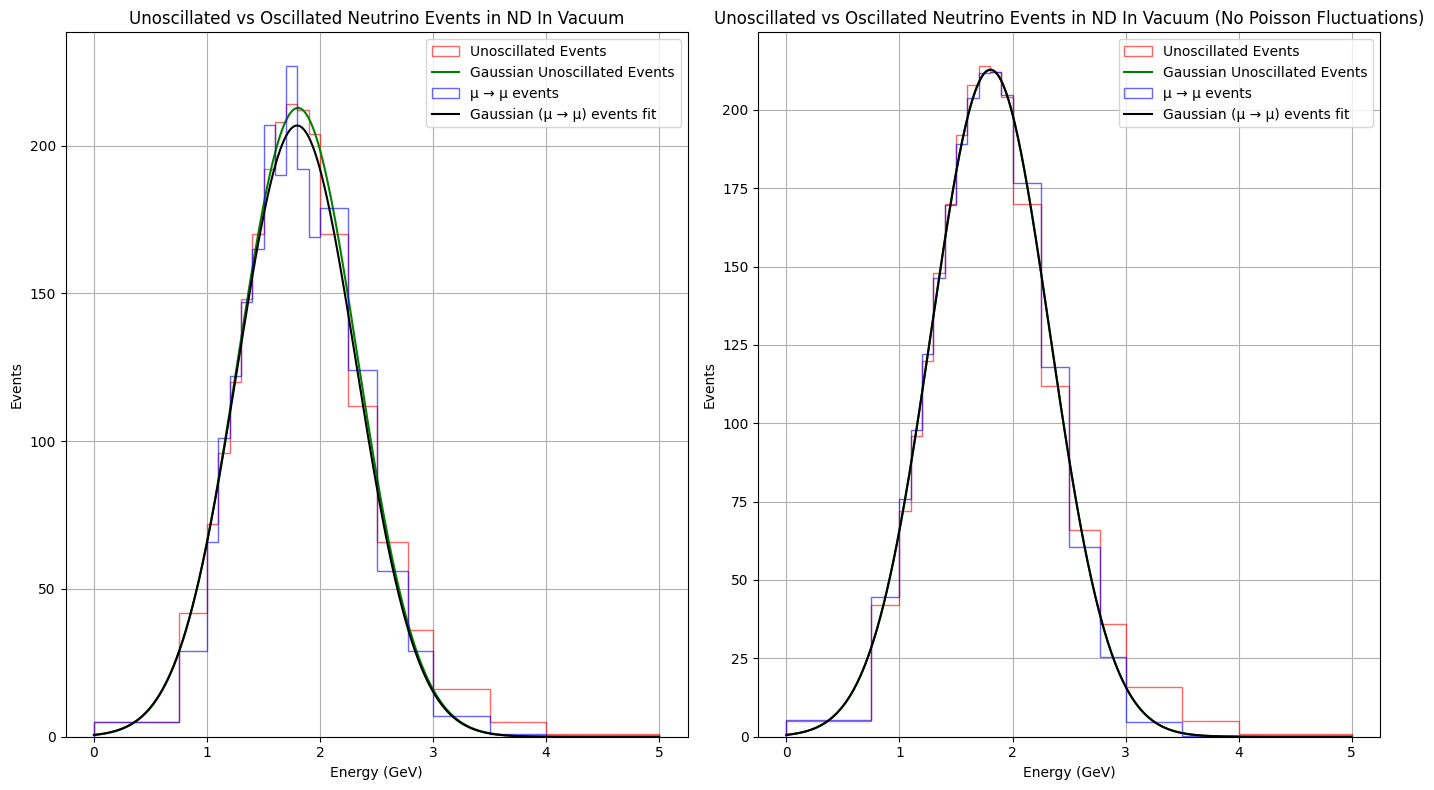

In [25]:
plot_osc_2nu_1(sector='23', case='vacuum', length=length_nd, transition='mm')
plot_osc_2nu(sector='23', case='vacuum', length=length_nd, transition='mm')


plot_osc_2nu_1(sector='23', case='vacuum', length=length_fd, transition='mm')
plot_osc_2nu_1(sector='23', case='vacuum', length=length_fd, transition='mt')
plot_osc_2nu_1(sector='12', case='vacuum', length=length_fd, transition='me')

plot_osc_2nu_1(sector='23', case='matter', length=length_fd, transition='mm')
plot_osc_2nu_1(sector='23', case='matter', length=length_fd, transition='mt')
plot_osc_2nu_1(sector='12', case='matter', length=length_fd, transition='me')

In [28]:
def plot_osc_2nu_scaled_fd(sector, case, length,transition):
    """
    Plots the scaled FD oscillation spectrum against simulated FD oscillations.

    Parameters:
    - sector: str, oscillation sector ('12' or '23')
    - case: str, either 'vacuum' or 'matter'
    - length: int, detector length (1, 810)
    - transition: str, type of transition ('me', 'mm', 'mt')
    """

    popt = popt_nd

    # Calcualte osc prob
    probabilities = osc_probability_2nu_1(sector, case, length, transition)
    print(f'Probabilitities: ', probabilities)

    # Set title and labels
    title_text2 = 'In Matter' if case == 'matter' else 'In Vacuum'
    full_title = f'FD Oscillations vs Simulated FD Oscillations {title_text2}'

    label_map = {
        'me': ('μ → e events', 'Gaussian (μ → e) events fit', 2),
        'mt': ('μ → τ events', 'Gaussian (μ → τ) events fit', 2),
        'mm': ('μ → μ events', 'Gaussian (μ → μ) events fit', 0),
    }
    event_label, gaussian_fit_label, index = label_map.get(transition, ('Unknown transition', '', 0))

    event_label1 = '(fluctuated)'
    full_event_label = f'{event_label} {event_label1}'
    
    # Calculate the Poisson-distributed counts for the oscillated events
    counts = poisson_dist(probabilities, x, *popt)
    unfluc_counts = probabilities * gaus(x, *popt)
    amount_count = np.sum(unfluc_counts)
    print(amount_count)

    bin_indices = np.digitize(x, bin_edges)
    fluc_bin_weights = np.zeros(len(bin_edges) - 1)
    unfluc_bin_weights = np.zeros(len(bin_edges) - 1)

    for i in range(1, len(bin_edges)):
        fluc_bin_weights[i-1] = counts[bin_indices == i].sum()
        unfluc_bin_weights[i-1] = unfluc_counts[bin_indices == i].sum()

    bin_widths = np.diff(bin_edges)
    scaling_factor = bin_widths * (1000 / 0.1)
    true_fluc_bin_weights = fluc_bin_weights / scaling_factor
    true_unfluc_bin_weights = unfluc_bin_weights / scaling_factor

    # Calculate scale factor
    scale_factor = np.sum(counts_fd) / np.sum(counts_nd)
    print(scale_factor)
    fluc_scaled_counts = true_fluc_bin_weights * 0.3260069192964826
    unfluc_scaled_counts = true_unfluc_bin_weights * 0.3260069192964826

    print('fluc sim unscaled fd data', np.sum(true_fluc_bin_weights))
    print('unfluc sim unscaled fd data', np.sum(true_unfluc_bin_weights))

    print('sim fd mm data', np.sum(fluc_scaled_counts))
    print('obs fd mm data', np.sum(counts_fd))


    # Plotting
    plt.figure(figsize=(12,8))
    
    # FD spectrum histogram
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='b', label='Observed Oscillated FD spectrum')

    plt.hist(bin_edges[:-1], bins=bin_edges, weights=fluc_scaled_counts, histtype='step',density=False,
             alpha=0.6, color='r', label=full_event_label)
    
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=unfluc_scaled_counts, histtype='step',density=False,
             alpha=0.6, color='g', label=event_label)

    # Labels and title to the plot
    plt.xlabel('Energy (GeV)')
    plt.ylabel('Events')
    plt.title(full_title)
    plt.legend()
    plt.grid()
    plt.show()

plot_osc_2nu_scaled_fd(sector='23', case='vacuum', length=length_fd, transition='mm')
plot_osc_2nu_scaled_fd(sector='23', case='vacuum', length=length_fd, transition='mt')
plot_osc_2nu_scaled_fd(sector='12', case='vacuum', length=length_fd, transition='me')

plot_osc_2nu_scaled_fd(sector='23', case='matter', length=length_fd, transition='mm')
plot_osc_2nu_scaled_fd(sector='23', case='matter', length=length_fd, transition='mt')
plot_osc_2nu_scaled_fd(sector='12', case='matter', length=length_fd, transition='me')

In [43]:
def get_osc_2nu(sector, case, length, transition):

    popt = popt_nd
    probabilities = osc_probability_2nu_1(sector, case, length, transition)

    counts = probabilities * gaus(x, *popt)
    fluc_counts = poisson_dist(probabilities, x, *popt)

    bin_indices = np.digitize(x, bin_edges)
    bin_weights = np.zeros(len(bin_edges) - 1)
    fluc_bin_weights = np.zeros(len(bin_edges) - 1)

    for i in range(1, len(bin_edges)):
        bin_weights[i-1] = counts[bin_indices == i].sum()
        fluc_bin_weights[i-1] = fluc_counts[bin_indices == i].sum()

    bin_widths = np.diff(bin_edges)
    binning_factor = bin_widths * (1000 / 0.1)

    true_bin_weights = bin_weights / binning_factor
    true_fluc_bin_weights = fluc_bin_weights / binning_factor

    scaled_counts = true_bin_weights * 0.3260069192964826
    scaled_fluc_counts = true_fluc_bin_weights * 0.3260069192964826

    return scaled_counts, scaled_fluc_counts


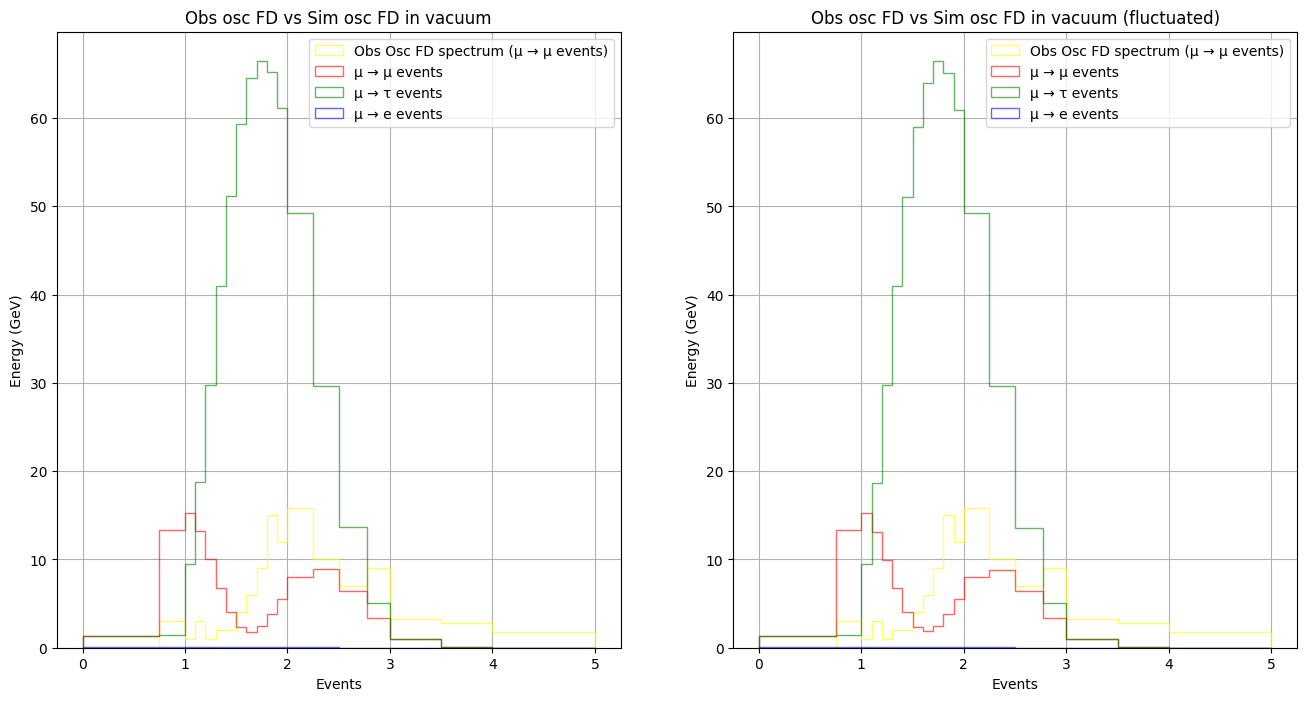

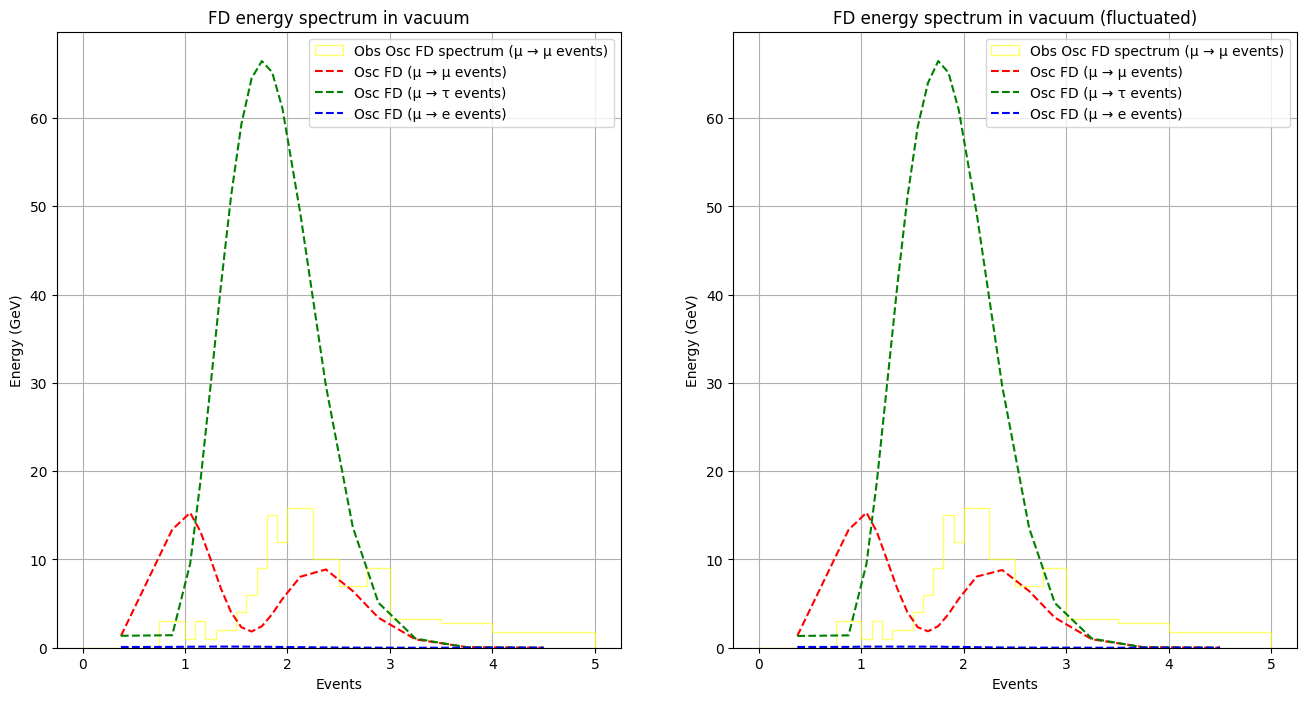

In [64]:
scaled_mm_fd, fluc_scaled_mm_fd = get_osc_2nu('23', 'vacuum', length_fd, 'mm')
scaled_mt_fd, fluc_scaled_mt_fd = get_osc_2nu(sector='23', case='vacuum', length=length_fd, transition='mt')
scaled_me_fd, fluc_scaled_me_fd = get_osc_2nu(sector='12', case='vacuum', length=length_fd, transition='me')

fig, axs = plt.subplots(1, 2, figsize=(16,8))

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='yellow', label='Obs Osc FD spectrum (μ → μ events)')

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=scaled_mm_fd, histtype='step',density=False,
             alpha=0.6, color='r', label='μ → μ events')

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=scaled_mt_fd, histtype='step',density=False,
             alpha=0.6, color='g', label='μ → τ events')

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=scaled_me_fd, histtype='step',density=False,
             alpha=0.6, color='b', label='μ → e events')

axs[0].set_title('Obs osc FD vs Sim osc FD in vacuum')
axs[0].set_xlabel('Events')
axs[0].set_ylabel('Energy (GeV)')
axs[0].legend()
axs[0].grid()


axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='yellow', label='Obs Osc FD spectrum (μ → μ events)')

axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=fluc_scaled_mm_fd, histtype='step',density=False,
             alpha=0.6, color='r', label='μ → μ events')

axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=fluc_scaled_mt_fd, histtype='step',density=False,
             alpha=0.6, color='g', label='μ → τ events')

axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=fluc_scaled_me_fd, histtype='step',density=False,
             alpha=0.6, color='b', label='μ → e events')

axs[1].set_title('Obs osc FD vs Sim osc FD in vacuum (fluctuated)')
axs[1].set_xlabel('Events')
axs[1].set_ylabel('Energy (GeV)')

axs[1].legend()
axs[1].grid()
plt.show()


fig, axs = plt.subplots(1, 2, figsize=(16,8))

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='yellow', label='Obs Osc FD spectrum (μ → μ events)')
axs[0].plot(bin_centers, scaled_mm_fd, 'r--', label=('Osc FD (μ → μ events)'))
axs[0].plot(bin_centers, scaled_mt_fd, 'g--', label=('Osc FD (μ → τ events)'))
axs[0].plot(bin_centers, scaled_me_fd, 'b--', label=('Osc FD (μ → e events)'))

axs[0].set_title('FD energy spectrum in vacuum')
axs[0].set_xlabel('Events')
axs[0].set_ylabel('Energy (GeV)')
axs[0].legend()
axs[0].grid()


axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='yellow', label='Obs Osc FD spectrum (μ → μ events)')
axs[1].plot(bin_centers, fluc_scaled_mm_fd, 'r--', label=('Osc FD (μ → μ events)'))
axs[1].plot(bin_centers, fluc_scaled_mt_fd, 'g--', label=('Osc FD (μ → τ events)'))
axs[1].plot(bin_centers, fluc_scaled_me_fd, 'b--', label=('Osc FD (μ → e events)'))

axs[1].set_title('FD energy spectrum in vacuum (fluctuated)')
axs[1].set_xlabel('Events')
axs[1].set_ylabel('Energy (GeV)')
axs[1].legend()
axs[1].grid()
plt.show()



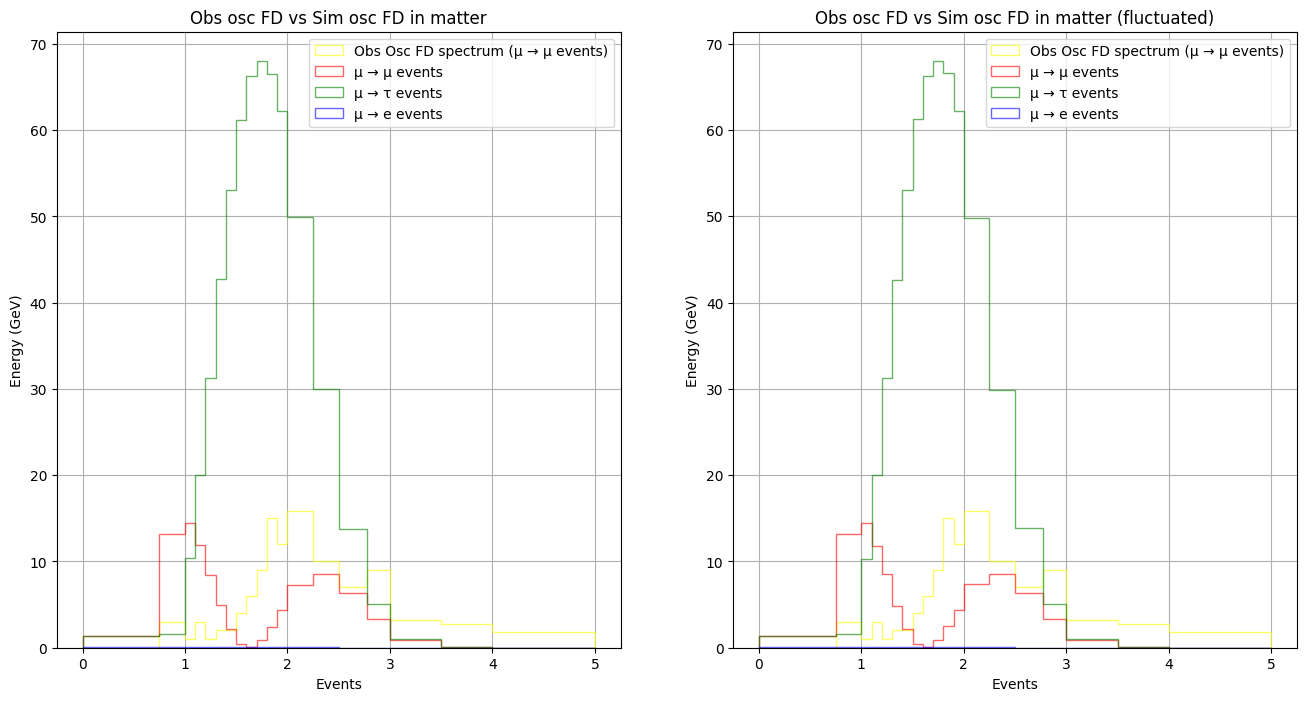

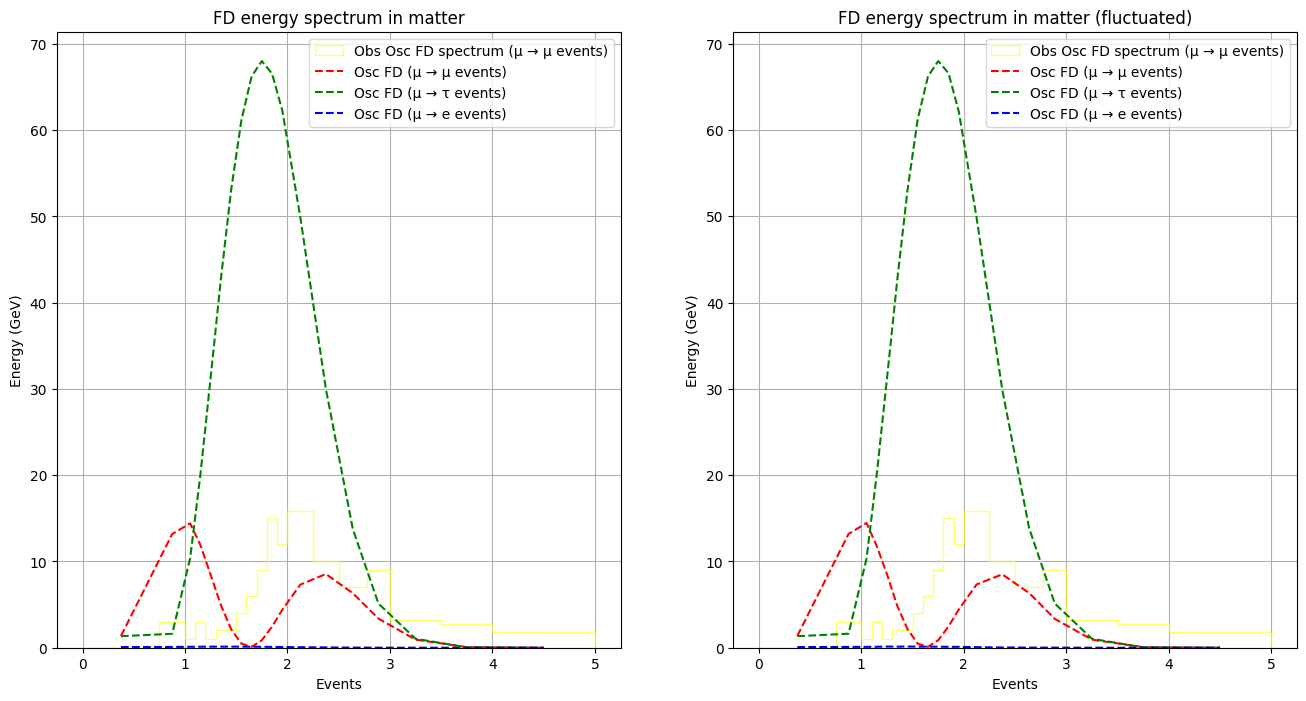

In [65]:
scaled_mm_fd_matter, fluc_scaled_mm_fd_matter = get_osc_2nu('23', 'matter', length_fd, 'mm')
scaled_mt_fd_matter, fluc_scaled_mt_fd_matter = get_osc_2nu(sector='23', case='matter', length=length_fd, transition='mt')
scaled_me_fd_matter, fluc_scaled_me_fd_matter = get_osc_2nu(sector='12', case='matter', length=length_fd, transition='me')

fig, axs = plt.subplots(1, 2, figsize=(16,8))

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='yellow', label='Obs Osc FD spectrum (μ → μ events)')

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=scaled_mm_fd_matter, histtype='step',density=False,
             alpha=0.6, color='r', label='μ → μ events')

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=scaled_mt_fd_matter, histtype='step',density=False,
             alpha=0.6, color='g', label='μ → τ events')

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=scaled_me_fd_matter, histtype='step',density=False,
             alpha=0.6, color='b', label='μ → e events')

axs[0].set_title('Obs osc FD vs Sim osc FD in matter')
axs[0].set_xlabel('Events')
axs[0].set_ylabel('Energy (GeV)')
axs[0].legend()
axs[0].grid()


axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='yellow', label='Obs Osc FD spectrum (μ → μ events)')

axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=fluc_scaled_mm_fd_matter, histtype='step',density=False,
             alpha=0.6, color='r', label='μ → μ events')

axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=fluc_scaled_mt_fd_matter, histtype='step',density=False,
             alpha=0.6, color='g', label='μ → τ events')

axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=fluc_scaled_me_fd_matter, histtype='step',density=False,
             alpha=0.6, color='b', label='μ → e events')

axs[1].set_title('Obs osc FD vs Sim osc FD in matter (fluctuated)')
axs[1].set_xlabel('Events')
axs[1].set_ylabel('Energy (GeV)')

axs[1].legend()
axs[1].grid()
plt.show()


fig, axs = plt.subplots(1, 2, figsize=(16,8))

axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='yellow', label='Obs Osc FD spectrum (μ → μ events)')
axs[0].plot(bin_centers, scaled_mm_fd_matter, 'r--', label=('Osc FD (μ → μ events)'))
axs[0].plot(bin_centers, scaled_mt_fd_matter, 'g--', label=('Osc FD (μ → τ events)'))
axs[0].plot(bin_centers, scaled_me_fd_matter, 'b--', label=('Osc FD (μ → e events)'))

axs[0].set_title('FD energy spectrum in matter')
axs[0].set_xlabel('Events')
axs[0].set_ylabel('Energy (GeV)')
axs[0].legend()
axs[0].grid()


axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='yellow', label='Obs Osc FD spectrum (μ → μ events)')
axs[1].plot(bin_centers, fluc_scaled_mm_fd_matter, 'r--', label=('Osc FD (μ → μ events)'))
axs[1].plot(bin_centers, fluc_scaled_mt_fd_matter, 'g--', label=('Osc FD (μ → τ events)'))
axs[1].plot(bin_centers, fluc_scaled_me_fd_matter, 'b--', label=('Osc FD (μ → e events)'))

axs[1].set_title('FD energy spectrum in matter (fluctuated)')
axs[1].set_xlabel('Events')
axs[1].set_ylabel('Energy (GeV)')
axs[1].legend()
axs[1].grid()
plt.show()